# 03. Parameter And Time Snapshot Reshape

This notebook uses the synthetic parameter-and-time field from the SparseSensing snapshot-reshape test. Five parameter values, eight times, and twenty spatial points produce a tensor of shape `(5, 8, 20)`, which becomes a `(40, 20)` matrix once the parameter and time axes are stacked into snapshots.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pysensors as ps

In [2]:
NX = 20
NT = 8
alphas = np.linspace(0.1, 1.0, 5)
X = np.linspace(0.0, 1.0, NX)
times = np.linspace(0.0, 1.0, NT)

tensor = np.stack(
    [np.exp(-times[:, None]) * np.sin((3.0 + alpha) * np.pi * X)[None, :] for alpha in alphas]
)

print(f"tensor shape: {tensor.shape}")
print(f"alpha values: {alphas}")

tensor shape: (5, 8, 20)
alpha values: [0.1   0.325 0.55  0.775 1.   ]


In [3]:
mat = tensor.reshape(len(alphas) * NT, NX)
model = ps.SSPOR(basis=ps.basis.SVD(n_basis_modes=4), n_sensors=4)
model.fit(mat, seed=42)
idx = model.get_selected_sensors()

pd.DataFrame({"sensor_index": idx, "x": X[idx]})

,sensor_index,x
0,19,1.000000
1,17,0.894737
2,11,0.578947
3,3,0.157895


/Users/abdomg/projects/SPSL-ViBRANT/.venv/lib/python3.11/site-packages/pysensors/reconstruction/_sspor.py:247: UserWarning: noise is None. noise will be set to the average of the computed prior
  warnings.warn(
/Users/abdomg/projects/SPSL-ViBRANT/.venv/lib/python3.11/site-packages/pysensors/reconstruction/_sspor.py:247: UserWarning: noise is None. noise will be set to the average of the computed prior
  warnings.warn(
/Users/abdomg/projects/SPSL-ViBRANT/.venv/lib/python3.11/site-packages/pysensors/reconstruction/_sspor.py:247: UserWarning: noise is None. noise will be set to the average of the computed prior
  warnings.warn(
/Users/abdomg/projects/SPSL-ViBRANT/.venv/lib/python3.11/site-packages/pysensors/reconstruction/_sspor.py:247: UserWarning: noise is None. noise will be set to the average of the computed prior
  warnings.warn(
/Users/abdomg/projects/SPSL-ViBRANT/.venv/lib/python3.11/site-packages/pysensors/reconstruction/_sspor.py:247: UserWarning: noise is None. noise will be set

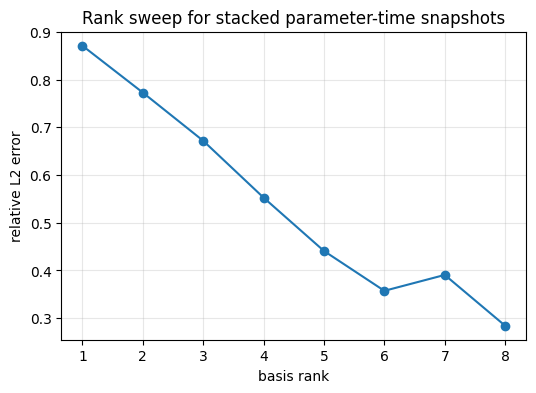

,rank,relative_l2_error
0,1,0.870856
1,2,0.772703
2,3,0.671719
3,4,0.552580
4,5,0.440860
5,6,0.357332
6,7,0.390643
7,8,0.284220


In [4]:
ranks = range(1, 9)
errors = []

for rank in ranks:
    fitted = ps.SSPOR(basis=ps.basis.SVD(n_basis_modes=rank), n_sensors=4)
    fitted.fit(mat, seed=42)
    chosen = fitted.get_selected_sensors()
    mat_hat = fitted.predict(mat[:, chosen])
    errors.append(np.linalg.norm(mat - mat_hat) / np.linalg.norm(mat))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(ranks), errors, "o-")
ax.set_xlabel("basis rank")
ax.set_ylabel("relative L2 error")
ax.set_title("Rank sweep for stacked parameter-time snapshots")
ax.grid(True, alpha=0.3)
plt.show()

pd.DataFrame({"rank": list(ranks), "relative_l2_error": errors})

The selected sensors tend to land where the family of spatial profiles changes the most across the parameter sweep. Increasing the basis rank lowers reconstruction error until the stacked snapshots have captured the dominant parameter-driven variation.

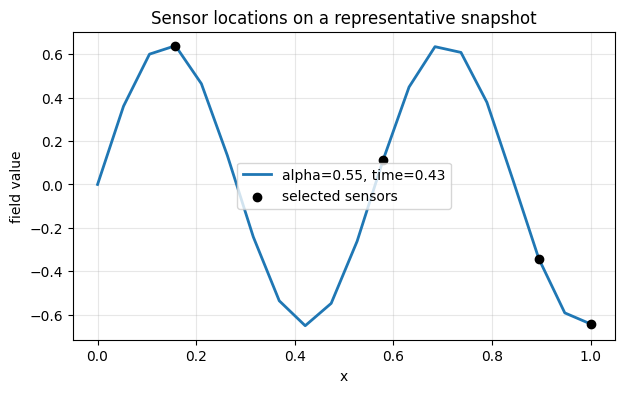

In [5]:
alpha_index = 2
time_index = 3
snapshot = tensor[alpha_index, time_index]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(X, snapshot, linewidth=2, label=f"alpha={alphas[alpha_index]:.2f}, time={times[time_index]:.2f}")
ax.scatter(X[idx], snapshot[idx], color="black", zorder=3, label="selected sensors")
ax.set_xlabel("x")
ax.set_ylabel("field value")
ax.set_title("Sensor locations on a representative snapshot")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()